In [67]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np
import xarray as xr
import gsw
from skimage import measure
from scipy import interpolate
import shapely.geometry as geometry
from shapely.ops import transform
from shapely import wkt
import pyproj

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
import datatools.plots.maps as mapper
from datatools.DOT import operations as satops
from datatools.DOT.DataServer import DataServer


In [69]:
#Load in Satellite Data
sat_data_server = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

#### Find and Plot the location of the Beaufort Gyre
The location of the Beaufot Gyre is plotted using the method described in Regan, et. al (2018). The location of the gyre is defined at the point of maximum DOT between 140˚E and 100˚W and 68-81.5˚N.

 the so-called "Beaufort Gyre Box" as defined in Proshutinsky et al., 2009 (with bounds 130-170˚W and 70.5-80.5˚N)

In [70]:
#Get raw satellite data Datasets
old_sat_data_ds, new_sat_data_ds = sat_data_server.datasets()

#Extract data from within the Beaufort Gyre box
lat_min, lat_max = 68, 81.5
lon_min, lon_max = 140, -100

#Old data (gridded on a 0.25˚ lat/lon grid)
if lon_min>lon_max:
    #If range crosses the int. date line
    mask = (
            (old_sat_data_ds.lat >= lat_min) & (old_sat_data_ds.lat <= lat_max) &
            ((old_sat_data_ds.lon >= lon_min) | (old_sat_data_ds.lon <= lon_max))
        )

    old_bg_ds = old_sat_data_ds.where(mask, drop=True)
else:
    old_bg_ds = old_sat_data_ds.sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))

#New data (gridded on a 20km grid on a polar stereographic projection)
if lon_min>lon_max:
    #If range crosses the int. date line
    mask = (
        (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
        ((new_sat_data_ds.lon >= lon_min) | (new_sat_data_ds.lon <= lon_max))
    )
else:
    mask = (
            (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
            (new_sat_data_ds.lon >= lon_min) & (new_sat_data_ds.lon <= lon_max)
        )

new_bg_ds = new_sat_data_ds.where(mask, drop=True)

#Discard all data not from September
old_bg_ds = old_bg_ds.where(old_bg_ds['time'].dt.month == 9, drop = True)
new_bg_ds = new_bg_ds.where(new_bg_ds['time'].dt.month == 9, drop = True)


In [ ]:
#Find max DOT for each year
old_max_DOT_dict = old_bg_ds['DOT'].argmax(dim = ['lat', 'lon'])
new_max_DOT_dict = new_bg_ds['DOT'].argmax(dim=['x','y'])

#Define function to find the x and y coords of a DOT value at a known lat/lon
def find_x_y(full_bg_dataarray, DOT_value, lat, lon, era):
    output = [np.nan, np.nan]
    if era == 'old':
        #x and y coords can be extracted directly from the lat/lon array
        output[0] = np.argwhere(full_bg_dataarray['lat'].values == lat)[0][0]
        output[1] = np.argwhere(full_bg_dataarray['lon'].values == lon)[0][0]
    if era == 'new':
        #Get all possible coordinates
        candidates = np.argwhere(full_bg_dataarray['DOT'].values == DOT_value)
        for index in candidates:
            x_coord = index[0]
            y_coord = index[1]
            #Work through the candidates until there is a match with the known lat/lon
            if full_bg_dataarray['lat'][x_coord][y_coord] == lat and full_bg_dataarray['lon'][x_coord][y_coord] == lon:
                #There is a match
                output = index
                break

    return output

#Redo calculation for 2003 because of a large "hill" near the bearing straight that is not the Beaufort Gyre
#Exclude data west of 160˚W and south of 71.5˚N
two_thousand_three_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2003, drop = True).sel(lat = slice(71.5, lat_max), lon = slice(-160,lon_max))
two_thousand_three_dict = two_thousand_three_data['DOT'].argmax(dim = ['lat', 'lon'])
lat = two_thousand_three_data['lat'][two_thousand_three_dict['lat']].values[0]
lon = two_thousand_three_data['lon'][two_thousand_three_dict['lon']].values[0]
DOT = two_thousand_three_data.sel(lat = lat, lon = lon)['DOT'].values[0]
old_max_DOT_dict['lat'][0], old_max_DOT_dict['lon'][0] = find_x_y(old_bg_ds.where(old_bg_ds['time'].dt.year == 2003, drop = True), DOT, lat, lon, 'old')

#Redo calculation for 2005 because of a large "hill" west of the the bearing straight that is not the Beaufort Gyre
#Exclude data south of 71.5˚N
two_thousand_five_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2005, drop = True).sel(lat = slice(71.5, lat_max))
two_thousand_five_dict = two_thousand_five_data['DOT'].argmax(dim = ['lat', 'lon'])
lat = two_thousand_five_data['lat'][two_thousand_five_dict['lat']].values[0]
lon = two_thousand_five_data['lon'][two_thousand_five_dict['lon']].values[0]
DOT = two_thousand_five_data.sel(lat = lat, lon = lon)['DOT'].values[0]
old_max_DOT_dict['lat'][2], old_max_DOT_dict['lon'][2] = find_x_y(old_bg_ds.where(old_bg_ds['time'].dt.year == 2005, drop = True), DOT, lat, lon, 'old')

#Redo calculation for 2006 because of a large "hill" near the bearing straight that is not the Beaufort Gyre
#Exclude data west of 160˚W and south of 71.5˚N
two_thousand_six_data = old_bg_ds.where(old_bg_ds['time'].dt.year == 2006, drop = True).sel(lat = slice(71.5, lat_max), lon = slice(-160,lon_max))
two_thousand_six_dict = two_thousand_six_data['DOT'].argmax(dim = ['lat', 'lon'])
lat = two_thousand_six_data['lat'][two_thousand_six_dict['lat']].values[0]
lon = two_thousand_six_data['lon'][two_thousand_six_dict['lon']].values[0]
DOT = two_thousand_six_data.sel(lat = lat, lon = lon)['DOT'].values[0]
old_max_DOT_dict['lat'][3], old_max_DOT_dict['lon'][3] = find_x_y(old_bg_ds.where(old_bg_ds['time'].dt.year == 2006, drop = True), DOT, lat, lon, 'old')


#Redo calculation for 2024 because of an eddy east of the BG
#Exclude data east of 134˚W
two_thousand_twenty_four_data = new_bg_ds.where(time_mask := new_bg_ds['time'].dt.year == 2024, drop = True)
if lon_min>-134:
    #If range crosses the int. date line
    mask = (
        (two_thousand_twenty_four_data.lat >= lat_min) & (two_thousand_twenty_four_data.lat <= lat_max) &
        ((two_thousand_twenty_four_data.lon >= lon_min) | (two_thousand_twenty_four_data.lon <= -134))
    )
else:
    mask = (
            (two_thousand_twenty_four_data.lat >= lat_min) & (two_thousand_twenty_four_data.lat <= lat_max) &
            (two_thousand_twenty_four_data.lon >= lon_min) & (two_thousand_twenty_four_data.lon <= -134)
        )

two_thousand_twenty_four_data = two_thousand_twenty_four_data.where(mask, drop=True)
two_thousand_twenty_four_dict = two_thousand_twenty_four_data['DOT'].argmax(dim = ['x', 'y'])
lat = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['lat'].values[0]
lon = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['lon'].values[0]
DOT = two_thousand_twenty_four_data.sel(x = two_thousand_twenty_four_dict['x'], y=two_thousand_twenty_four_dict['y'])['DOT'].values[0]
new_max_DOT_dict['x'][13], new_max_DOT_dict['y'][13] = find_x_y(new_bg_ds.sel(time = np.datetime64(f"2024-09-01")), DOT, lat, lon, 'new')

#Extract lat/lon coordinates and DOT value from coordinate array indicies from argmax
old_lats, old_lons = old_bg_ds['lat'][old_max_DOT_dict['lat']].values.copy(), old_bg_ds['lon'][old_max_DOT_dict['lon']].values.copy()
old_DOT = np.full_like(old_lats, np.nan)
old_x = old_max_DOT_dict['lat']
old_y = old_max_DOT_dict['lon']
for i in range (old_DOT.size):
    old_DOT[i] = old_bg_ds['DOT'].sel(lat = old_lats[i], lon = old_lons[i]).values.copy()[i]

new_lats, new_lons, new_DOT = new_bg_ds['lat'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y']), new_bg_ds['lon'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y']), new_bg_ds['DOT'].sel(x = new_max_DOT_dict['x'], y = new_max_DOT_dict['y'])
new_x = new_max_DOT_dict['x']
new_y = new_max_DOT_dict['y']

#Package into a Dataset for easy access
times = np.unique(np.concat((old_bg_ds.time, new_bg_ds.time)))
old_padding_size = (times.size-old_bg_ds.time.size,) #Size of padding to add after any old data
new_padding_size = (times.size-new_bg_ds.time.size,) #Size of padding to add before any new data
era = np.array(['old', 'new'], dtype=str)

page_size = (era.size, times.size)

#Assemble data
old_data_arrays = [old_lats, old_lons, old_DOT, old_x, old_y]
new_data_arrays = [new_lats, new_lons, new_DOT, new_x, new_y]
data = np.ndarray(shape=(era.size, times.size,len(old_data_arrays)))

for i in range(len(old_data_arrays)):
    old_row = np.hstack((old_data_arrays[i], np.full(old_padding_size, np.nan)))
    new_row = np.hstack((np.full(new_padding_size, np.nan), new_data_arrays[i]))
    data[:,:,i] = np.vstack((old_row, new_row))

#Create Dataset
gyre_metrics = xr.Dataset(
    {
        "max_DOT_lat": 
            (['era', 'time'],
             data[:,:,0],
             {"units": "degrees",
              "long_name": "Maximum DOT Latitude",
              'standard_name': "maximum_DOT_latitude"}),
        "max_DOT_lon": 
            (['era', 'time'],
                data[:,:,1],
                {"units": "degrees",
                "long_name": "Maximum DOT Longitude",
                'standard_name': "maximum_DOT_longitude"}),
        "max_DOT": 
            (['era', 'time'],
                data[:,:,2],
                {"units": "meters",
                "long_name": "Dynamic Ocean Topography",
                'standard_name': "DOT"}),
        "x":
            (['era', 'time'],
             data[:,:,3],
             {"units": "array index"}),
        "y":
            (['era', 'time'],
                data[:,:,4],
                {"units": "array index"}),
    },
    coords={
        "time": times,
        "era": era,
    },
    attrs = {
        "title": "Location and Size Metrics for the Beaufort Gyre from 2003-2025"
    }
)

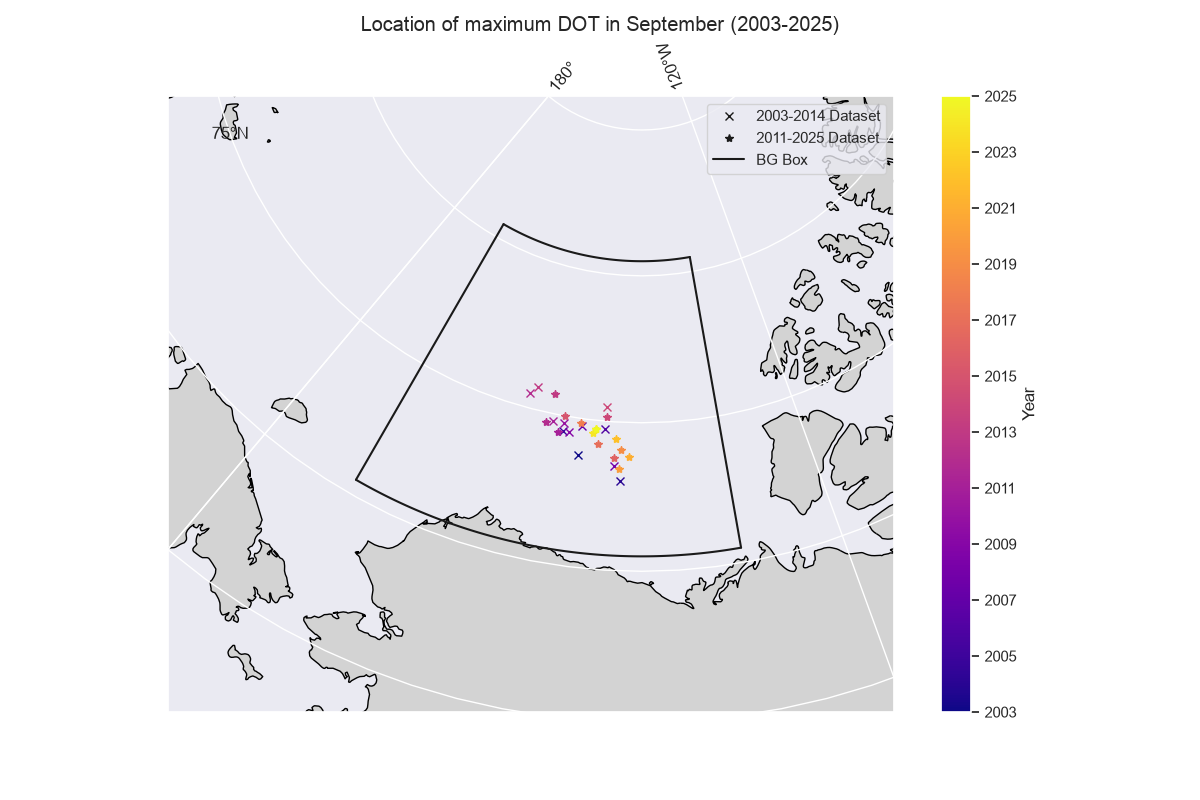

In [ ]:
#Plot location of max DOT
extent = [-180, -120, 65, 85]

dot_figure = plt.figure(figsize=(12,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
ax = mapper.setup_map(figure=dot_figure,
                      projection=projection,
                      extent=extent)

sns.set_theme()

years = gyre_metrics['time'].dt.year
colors = plt.cm.plasma(np.linspace(0, 1, len(years)))


for i, year in enumerate(years):
    working_data = gyre_metrics.where(gyre_metrics['time'].dt.year == year)
    #Plot old data
    ax.plot(working_data.sel(era = 'old')['max_DOT_lon'], working_data.sel(era = 'old')['max_DOT_lat'], marker = 'x', color = colors[i], transform = ccrs.PlateCarree())

    #Plot new data
    ax.plot(working_data.sel(era = 'new')['max_DOT_lon'], working_data.sel(era = 'new')['max_DOT_lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
    
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(years.min(), years.max()))
sm.set_array([])
cbar = dot_figure.colorbar(sm, ax=ax)
cbar.set_label('Year')
tick_years = years.values[::2]  # every other year
cbar.set_ticks(tick_years)
cbar.set_ticklabels([str(y) for y in tick_years])

#Create dummy points for the legend
ax.plot([],[],'kx', label = '2003-2014 Dataset')
ax.plot([],[],'k*', label = '2011-2025 Dataset')

#Plot the Beaufort Gyre Box
top_bottom_lon= np.linspace(-170, -130, 100)
top_lat = np.full_like(top_bottom_lon, 80.5)
bottom_lat = np.full_like(top_bottom_lon, 70.5)
ax.plot([-170, -170], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree(), label = 'BG Box')
ax.plot([-130, -130], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, top_lat, 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, bottom_lat, 'k-', transform = ccrs.PlateCarree())

ax.legend()

dot_figure.suptitle("Location of maximum DOT in September (2003-2025)")


plt.show()

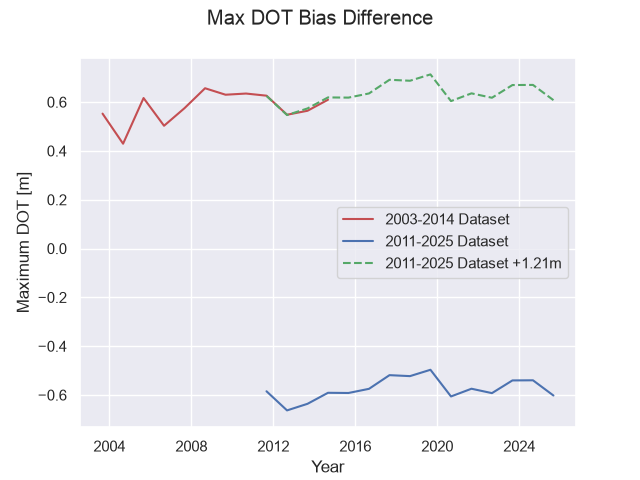

In [87]:
#Plot max DOT bias between datasets
bias_fig = plt.figure()
plt.plot(old_bg_ds['time'], np.nanmax(old_bg_ds['DOT'].values, axis = (0,1)), 'r-', label = '2003-2014 Dataset')
plt.plot(new_bg_ds['time'], np.nanmax(new_bg_ds['DOT'].values, axis = (1,2)), 'b-', label = '2011-2025 Dataset')
plt.plot(new_bg_ds['time'], np.nanmax(new_bg_ds['DOT'].values, axis = (1,2))+1.21, 'g--', label = '2011-2025 Dataset +1.21m')
plt.legend()
plt.suptitle("Max DOT Bias Difference")
plt.xlabel("Year")
plt.ylabel("Maximum DOT [m]")
plt.show()

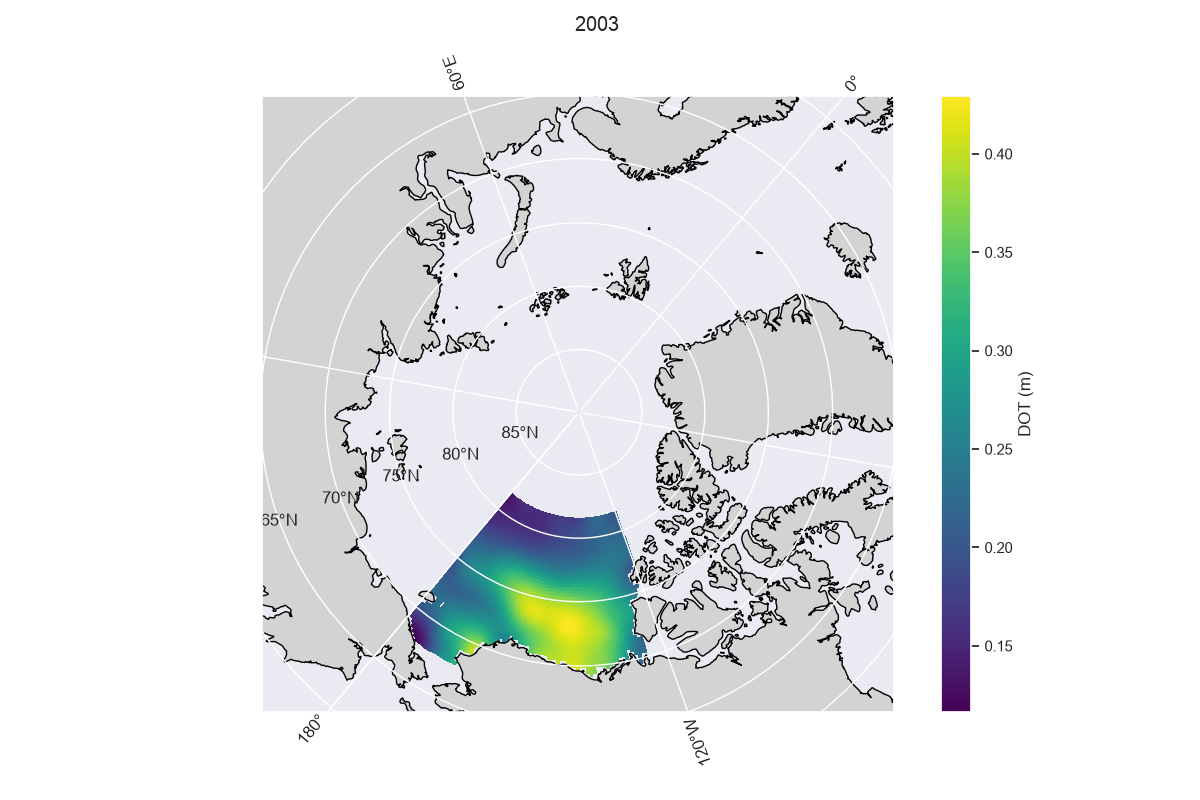

In [73]:
if True:
    #Plot single year DOT
    # extent = [-180, -120, 65, 85]
    extent = [-120, 140, 65, 85]


    year = 2004

    sat_data = old_sat_data_ds.sel(lat = slice(68, lat_max), lon = slice(-180, -120)).where(old_sat_data_ds['time'].dt.year == year, drop=True)
    sat_data = sat_data.where(sat_data['time'].dt.month == 9, drop=True)

    # sat_data = new_sat_data_ds.where(new_sat_data_ds['time'].dt.year == year, drop=True)
    # sat_data = sat_data.where(sat_data['time'].dt.month == 9, drop=True)
    # mask = (
    #             (new_sat_data_ds.lat >= lat_min) & (new_sat_data_ds.lat <= lat_max) &
    #             ((new_sat_data_ds.lon >= lon_min) | (new_sat_data_ds.lon <= -134))
    #         )

    # sat_data = sat_data.where(mask, drop=True)

    year_dot_figure = plt.figure(figsize=(12,8))
    projection=ccrs.NorthPolarStereo(central_longitude=-140)
    ax = mapper.setup_map(figure=year_dot_figure,
                        projection=projection,
                        extent=extent)

    sns.set_theme()

    sat_data = sat_data.sel(time = sat_data['time'][0])

    lon_mesh, lat_mesh = np.meshgrid(sat_data['lon'], sat_data['lat'])
    mesh = ax.pcolormesh(lon_mesh, lat_mesh, sat_data['DOT'], cmap = 'viridis', shading='auto', transform = ccrs.PlateCarree())
    # step = 2
    # # mesh = ax.quiver(x = sat_data['lon'].values[::step],  y = sat_data['lat'].values[::step], u = sat_data['U'].values[::step], v = sat_data["V"].values[::step], cmap='viridis', transform = ccrs.PlateCarree())
    # dir = angle_rad = (np.arctan2(sat_data["V"].values, sat_data["U"].values)*180/np.pi +360) % 360 
    # mesh = ax.scatter(sat_data['lon'].values, sat_data['lat'].values, c= sat_data['DOT'].values, cmap='viridis', s = 8, transform = ccrs.PlateCarree())

    plt.colorbar(mesh, label = 'DOT (m)')
    year_dot_figure.suptitle("2003 ")

    plt.show()

In [ ]:
gyre_metrics = gyre_metrics.assign(extent = xr.full_like(gyre_metrics['max_DOT'], "", dtype=object))
gyre_metrics = gyre_metrics.assign(min_DOT = xr.full_like(gyre_metrics['max_DOT'], np.nan))

percision = 2
step = 10**(-percision)

def get_closed_contour_around_point(data, level, point_x, point_y):
    #Find all contours at that level
    contours = measure.find_contours(data, level)
    #Check if any contours are closed
    if np.array(mask := [np.isclose(contour[0], contour[-1]).all() for contour in contours]).any():
        #Discard all open contours
        contours = [closed_contour for closed_contour, mask_entry in zip(contours, mask) if mask_entry]
        if (mask:= np.array([measure.points_in_poly(np.array([[point_x, point_y]]), contour)[0] for contour in contours])).any():
            #If there is a contour with the point in it
            closed_contour_around_point = [contour for contour, mask_entry in zip(contours, mask) if mask_entry][0]
            return np.array(closed_contour_around_point, dtype=np.int64)
        else:
            return None
    else:
        return None 
for era in gyre_metrics['era']:
    for time in gyre_metrics['time']:
        working_DOT_da = gyre_metrics.sel(time = time, era = era)
        if ~np.isnan(working_DOT_da['max_DOT']):
            #If the current time/era combination is valid
            if era == 'old':
                working_bg_ds = old_bg_ds
            elif era == 'new':
                working_bg_ds = new_bg_ds

            data = working_bg_ds['DOT'].sel(time = time).values.copy()
            data = np.round(data, percision)
            working_height = np.nanmin(data)

            #Find the BG extent contour
            while working_height < working_DOT_da['max_DOT'].copy():
                #Work up from the min height to find the lowest closed contour that contains the max DOT point 

                #Get the location of the max DOT point in array coordinate space
                working_x_coord = working_DOT_da['x']
                working_y_coord = working_DOT_da['y']

                if (contour := get_closed_contour_around_point(data, working_height, working_x_coord, working_y_coord)) is not None:
                    #If there is a closed contour at the working_height around the max DOT point, break
                    break 
                else:
                    #If there is no closed contour at the working height, increase the working height
                    working_height += step


            contour = get_closed_contour_around_point(data, working_height, working_x_coord, working_y_coord)

            if era == 'old':
                lon_mesh, lat_mesh = np.meshgrid(working_bg_ds.sel(time = time)['lon'], working_bg_ds.sel(time = time)['lat'])
                interp_lat = interpolate.RegularGridInterpolator((np.arange(working_bg_ds.sel(time = time)['lat'].size), np.arange(working_bg_ds.sel(time = time)['lon'].size)), lat_mesh, method = 'linear')
                interp_lon = interpolate.RegularGridInterpolator((np.arange(working_bg_ds.sel(time = time)['lat'].size), np.arange(working_bg_ds.sel(time = time)['lon'].size)), lon_mesh, method = 'linear')
            elif era == 'new':
                interp_lat = interpolate.RegularGridInterpolator((working_bg_ds.sel(time = time)['x'].values, working_bg_ds.sel(time = time)['y'].values), working_bg_ds.sel(time = time)['lat'].values, method = 'linear')
                interp_lon = interpolate.RegularGridInterpolator((working_bg_ds.sel(time = time)['x'].values, working_bg_ds.sel(time = time)['y'].values), working_bg_ds.sel(time = time)['lon'].values, method = 'linear')

            closed_lat = interp_lat(contour)
            closed_lon = interp_lon(contour)
    
            gyre_metrics['extent'].loc[{'time': time, 'era': era}] = geometry.Polygon(np.vstack((closed_lon, closed_lat)).T).wkt
            gyre_metrics['min_DOT'].loc[{'time': time, 'era': era}] = working_height
            



In [ ]:
#Calculate the area, centroid, mean radius, and strength of the Beaufort Gyre
gyre_metrics = gyre_metrics.assign(area = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(centroid_lon = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(centroid_lat = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(mean_radius = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(max_radius = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(min_radius = xr.full_like(gyre_metrics['max_DOT'], np.nan))
gyre_metrics = gyre_metrics.assign(strength = xr.full_like(gyre_metrics['max_DOT'], np.nan))

#Set up transform to go from lat/lon to equal area coordinate spaces
wgs_to_laea = pyproj.Transformer.from_crs(
                "EPSG:4326",   # WGS84 lat/lon
                "EPSG:3573", # WGS 84 / North Pole LAEA Canada, a Lambert Azimuthal Equal Area projection
                always_xy=True
            ).transform
laea_to_wgs = pyproj.Transformer.from_crs(
                "EPSG:3573", # WGS 84 / North Pole LAEA Canada, a Lambert Azimuthal Equal Area projection
                "EPSG:4326",   # WGS84 lat/lon
                always_xy=True
            ).transform

for era in gyre_metrics['era']:
    for time in gyre_metrics['time']:
        working_DOT_da = gyre_metrics.sel(time = time, era = era)
        if ~np.isnan(working_DOT_da['max_DOT']):
            #If the current time/era combination is valid
            #Transform the polygon from lat/lon coordinate space to distances
            polygon = wkt.loads(gyre_metrics.sel(time = time, era = era)['extent'].values)
            projected_polygon = transform(wgs_to_laea, polygon)

            #Calculate the Area
            area_km2 = projected_polygon.area / 1e6
            gyre_metrics['area'].loc[{'time': time, 'era': era}] = area_km2

            #Calculate the centroid
            centroid_x, centroid_y = projected_polygon.centroid.x, projected_polygon.centroid.y
            gyre_metrics['centroid_lon'].loc[{'time': time, 'era': era}], gyre_metrics['centroid_lat'].loc[{'time': time, 'era': era}] = laea_to_wgs(centroid_x, centroid_y)

            #Calculate the mean radius

            #Transform the location of the max DOT location into equal area coordinate space
            max_DOT_x, max_DOT_y = wgs_to_laea(working_DOT_da['max_DOT_lon'], working_DOT_da['max_DOT_lat'])
            contour_xy = satops.polygon_to_array(projected_polygon)

            #Calculate the distance from the max DOT to each point on the min DOT contour and find the mean
            dists = np.hypot(contour_xy[:,0] - max_DOT_x, contour_xy[:,1] - max_DOT_y)
            mean_radius_km = dists.mean()/1000
            gyre_metrics['mean_radius'].loc[{'time': time, 'era': era}] = mean_radius_km
            gyre_metrics['max_radius'].loc[{'time': time, 'era': era}] = np.nanmax(dists)/1000
            gyre_metrics['min_radius'].loc[{'time': time, 'era': era}] = np.nanmin(dists)/1000

#Calculate the gyre strength using the equation from Proshutinsky and Johnson (1997)
gyre_metrics['strength'] = (gyre_metrics['max_DOT'] - gyre_metrics['min_DOT'])/(gyre_metrics['mean_radius']*1000)



    
    


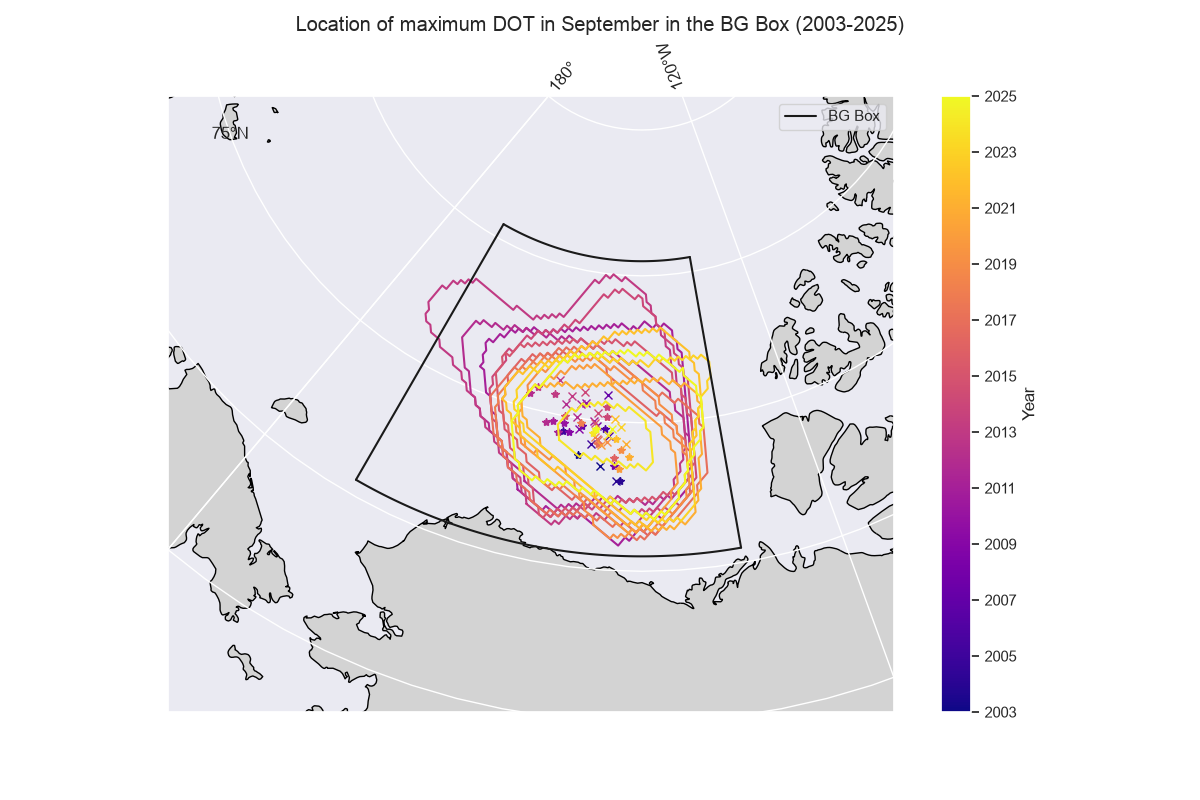

In [ ]:
#Plot location of max DOT and min DOT contour
extent = [-180, -120, 65, 85]

dot_figure = plt.figure(figsize=(12,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
ax = mapper.setup_map(figure=dot_figure,
                      projection=projection,
                      extent=extent)

sns.set_theme()
    



years = np.arange(2003,2026)
colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    working_data = gyre_metrics.sel(time = np.datetime64(f'{year}-09-01'), era = 'old')
    if working_data['extent'].values != "":
        bg_extent = wkt.loads(working_data['extent'].values)
        points = satops.polygon_to_array(bg_extent)


        ax.plot(working_data['max_DOT_lon'], working_data['max_DOT_lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
        ax.plot(working_data['centroid_lon'], working_data['centroid_lat'], marker = 'x', color = colors[i], transform = ccrs.PlateCarree())
            
        ax.plot(points[:,1], points[:,0], linestyle = '-', color = colors[i], transform = ccrs.PlateCarree())
    working_data = gyre_metrics.sel(time = np.datetime64(f'{year}-09-01'), era = 'new')
    if working_data['extent'].values != "":
        bg_extent = wkt.loads(working_data['extent'].values)
        points = satops.polygon_to_array(bg_extent)


        ax.plot(working_data['max_DOT_lon'], working_data['max_DOT_lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
        ax.plot(working_data['centroid_lon'], working_data['centroid_lat'], marker = 'x', color = colors[i], transform = ccrs.PlateCarree())
                    
        ax.plot(points[:,0], points[:,1], linestyle = '-', color = colors[i], transform = ccrs.PlateCarree())

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(years.min(), years.max()))
sm.set_array([])
cbar = dot_figure.colorbar(sm, ax=ax)
cbar.set_label('Year')
tick_years = years[::2]  # every other year
cbar.set_ticks(tick_years)
cbar.set_ticklabels([str(y) for y in tick_years])
#Plot the Beaufort Gyre Box
top_bottom_lon= np.linspace(-170, -130, 100)
top_lat = np.full_like(top_bottom_lon, 80.5)
bottom_lat = np.full_like(top_bottom_lon, 70.5)
ax.plot([-170, -170], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree(), label = 'BG Box')
ax.plot([-130, -130], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, top_lat, 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, bottom_lat, 'k-', transform = ccrs.PlateCarree())

ax.legend()

dot_figure.suptitle("Location of maximum DOT in September in the BG Box (2003-2025)")


plt.show()

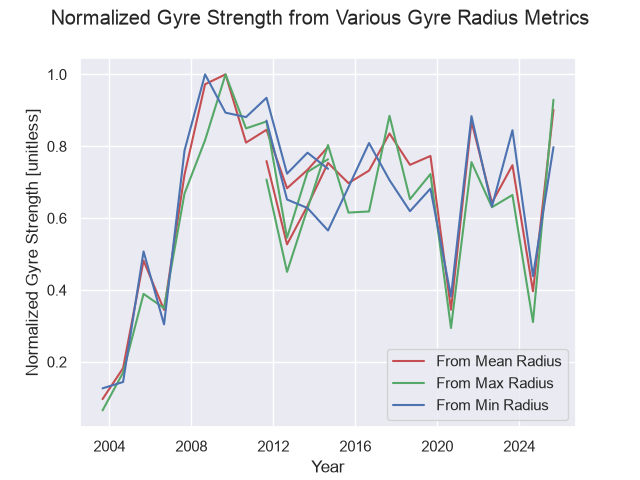

In [ ]:
max_r_strength = (gyre_metrics['max_DOT'] - gyre_metrics['min_DOT'])/(gyre_metrics['max_radius']*1000)
min_r_strength = (gyre_metrics['max_DOT'] - gyre_metrics['min_DOT'])/(gyre_metrics['min_radius']*1000)


plt.figure()
plt.plot(gyre_metrics['time'].broadcast_like(gyre_metrics['strength']).values.flatten(), gyre_metrics['strength'].values.flatten()/np.nanmax(gyre_metrics['strength'].values),'r-', label = 'From Mean Radius')
plt.plot(gyre_metrics['time'].broadcast_like(gyre_metrics['strength']).values.flatten(), max_r_strength.values.flatten()/np.nanmax(max_r_strength.values), 'g-', label = 'From Max Radius')
plt.plot(gyre_metrics['time'].broadcast_like(gyre_metrics['strength']).values.flatten(), min_r_strength.values.flatten()/np.nanmax(min_r_strength.values), 'b-', label = 'From Min Radius')
plt.legend()
plt.suptitle("Normalized Gyre Strength from Various Gyre Radius Metrics")
plt.xlabel("Year")
plt.ylabel("Normalized Gyre Strength")
plt.show()
